<a href="https://colab.research.google.com/github/divij07-04/Hospital-Management-system/blob/main/Credit_Card_Default_old.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [ ]:
import os
folders = ['data', 'notebooks','outputs', 'src']
for folder in folders:
    os.makedirs(folder, exist_ok=True)


In [ ]:
cd src

/content/credit-card-default-prediction/src


In [ ]:
%cd /content/drive/MyDrive/credit-card-default-prediction

/content/drive/MyDrive/credit-card-default-prediction


In [ ]:
cd data

/content/drive/MyDrive/credit-card-default-prediction/data


/root


In [ ]:
ls

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/content
/content/credit-card-default-prediction
.:
data  notebooks  outputs  README.md  requirements.txt  src

./data:

./notebooks:

./outputs:
figures  models

./outputs/figures:

./outputs/models:

./src:
utils.py


In [ ]:
!pwd

/content/drive/My Drive/credit-card-default-prediction/data


In [ ]:
# ── Install extra libraries ───────────────────────────────
!pip install shap imbalanced-learn xgboost -q

# ── Core imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

# ── sklearn ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             f1_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap

# ── Output directories ────────────────────────────────────
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/models",  exist_ok=True)

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


In [ ]:
# ── Load raw data ─────────────────────────────────────────
# Option A: Manual upload to Colab
df = pd.read_csv('UCI_Credit_Card.csv')

# Option B: opendatasets (no API key needed)
# !pip install opendatasets -q
# import opendatasets as od
# od.download("https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset")
# df = pd.read_csv('default-of-credit-card-clients-dataset/UCI_Credit_Card.csv')

print(f"Shape: {df.shape}")
print("\nSample rows:")
df.head()

Shape: (30000, 25)

Sample rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
!cp -r /content/credit-card-default-prediction /content/drive/MyDrive/

cp: cannot stat '/content/credit-card-default-prediction': No such file or directory


In [ ]:
# ════════════════════════════════════════════════
# ALL HELPER FUNCTIONS — defined once, called often
# ════════════════════════════════════════════════

def remove_outliers_iqr(df, col):
    """Remove rows outside 1.5×IQR bounds for given column."""
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

def draw_cm(y_true, y_pred, title="Confusion Matrix"):
    """Plot and display a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default","Default"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return cm

def print_metrics(y_true, y_pred, y_prob, model_name="Model"):
    """Print full classification metrics for a model."""
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_true, y_pred):.4f}")
    print(f"  AUC-ROC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['No Default','Default'])}")

def youden_threshold(y_true, y_prob):
    """Find optimal threshold via Youden's Index = max(TPR - FPR)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[youden_idx]
    best_j      = (tpr - fpr)[youden_idx]
    return best_thresh, best_j, fpr, tpr, thresholds

def business_cost(y_true, y_prob, thresholds, fn_weight=5, fp_weight=1):
    """Compute business cost at each threshold. FN cost > FP cost (default missed = worse)."""
    costs = []
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        fn = ((preds == 0) & (y_true == 1)).sum()
        fp = ((preds == 1) & (y_true == 0)).sum()
        costs.append(fn * fn_weight + fp * fp_weight)
    return np.array(costs)

def get_highly_correlated(df, threshold=0.95):
    """Return list of feature pairs with |correlation| above threshold."""
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = [(col, row) for col in upper.columns for row in upper.index
             if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > threshold]
    to_drop = list(set([pair[0] for pair in pairs]))
    return to_drop, pairs

print("✅ All helper functions defined")

✅ All helper functions defined


In [ ]:
# ── Rename target + drop ID ───────────────────────────────
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)
df.drop('ID', axis=1, inplace=True, errors='ignore')

# ── Null check ────────────────────────────────────────────
print("Null counts per column:")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")  # Expected: 0

Null counts per column:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

Total nulls: 0


In [ ]:
# ── Duplicate rows ────────────────────────────────────────
print(f"Duplicate rows before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after : {df.duplicated().sum()}")
print(f"Shape after dedup    : {df.shape}")

Duplicate rows before: 35
Duplicate rows after : 0
Shape after dedup    : (29965, 24)


In [ ]:
# ── Fix invalid category codes ────────────────────────────
# EDUCATION: 0,5,6 not documented → merge to 'Other'(4)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
# MARRIAGE: 0 not documented → merge to 'Other'(3)
df['MARRIAGE']  = df['MARRIAGE'].replace({0: 3})

print("EDUCATION value counts after fix:")
print(df['EDUCATION'].value_counts().sort_index())
print("\nMARRIAGE value counts after fix:")
print(df['MARRIAGE'].value_counts().sort_index())

EDUCATION value counts after fix:
EDUCATION
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64

MARRIAGE value counts after fix:
MARRIAGE
1    13643
2    15945
3      377
Name: count, dtype: int64


In [ ]:
# ── IQR outlier removal for LIMIT_BAL & AGE ──────────────
shape_before = df.shape

# Safety check: Rename target if it hasn't been done yet
if 'default.payment.next.month' in df.columns:
    df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

for col in ['LIMIT_BAL', 'AGE']:
    df = remove_outliers_iqr(df, col)

print(f"Rows before outlier removal: {shape_before[0]}")
print(f"Rows after  outlier removal: {df.shape[0]}")
print(f"Rows removed: {shape_before[0] - df.shape[0]}")

# ── Class distribution check ──────────────────────────────
print("\nClass distribution after cleaning:")
if 'default' in df.columns:
    print(df['default'].value_counts())
    print(df['default'].value_counts(normalize=True).round(3))
else:
    print("Error: Target column 'default' not found. Please re-run the data loading cell.")

Rows before outlier removal: 29965
Rows after  outlier removal: 29529
Rows removed: 436

Class distribution after cleaning:
default
0    22991
1     6538
Name: count, dtype: int64
default
0    0.779
1    0.221
Name: proportion, dtype: float64


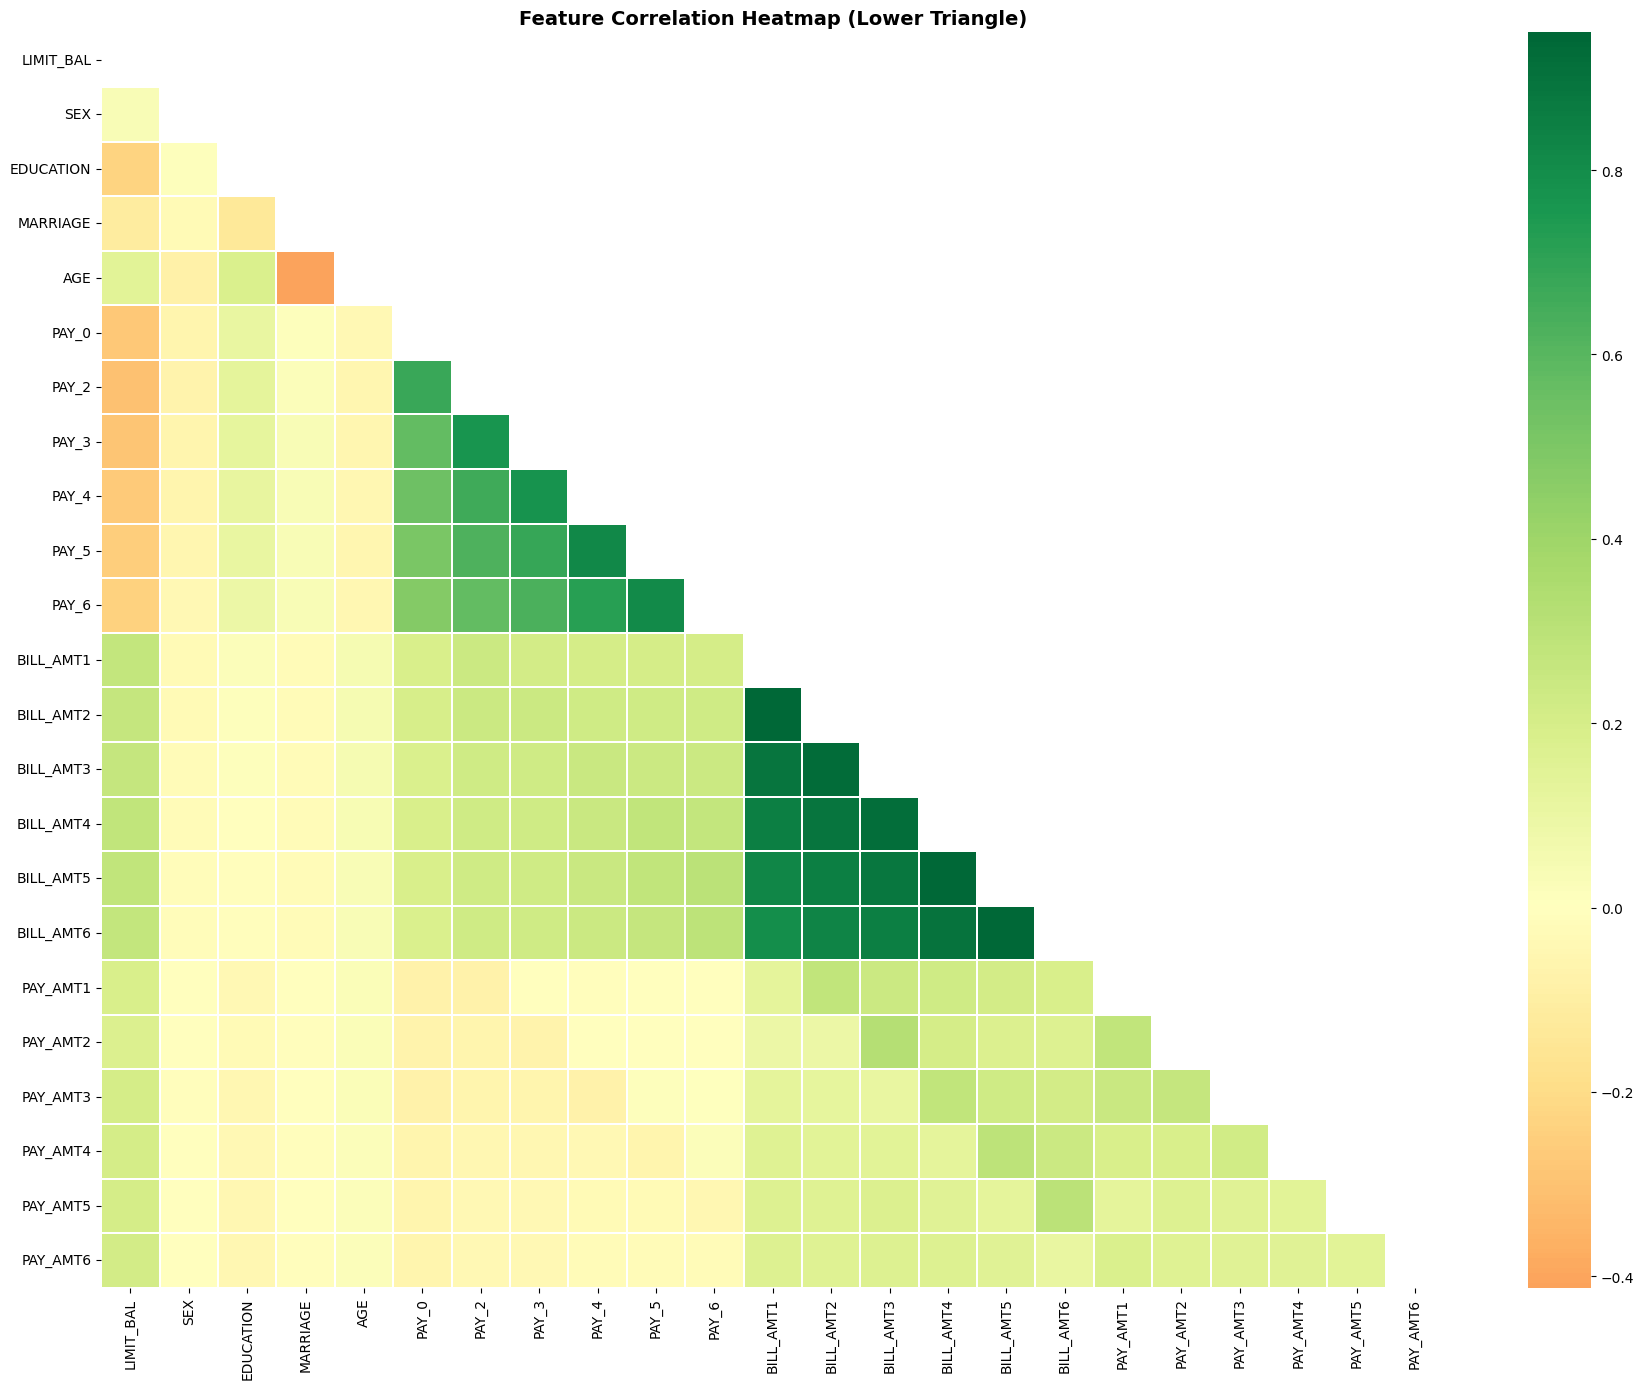

In [ ]:
# ── Full correlation heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(18, 14))
corr_matrix = df.drop('default', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdYlGn',
            center=0, linewidths=0.3, ax=ax)
ax.set_title("Feature Correlation Heatmap (Lower Triangle)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Identify and drop highly correlated features (|r| > 0.95) ──
to_drop, high_corr_pairs = get_highly_correlated(df.drop('default', axis=1), threshold=0.95)

print("Highly correlated pairs (|r| > 0.95):")
for a, b in high_corr_pairs:
    print(f"  {a}  <-->  {b}  r={df[a].corr(df[b]):.3f}")

print(f"\nColumns to drop: {to_drop}")
# NOTE: BILL_AMT2–6 are highly correlated with BILL_AMT1 (consecutive months)
# We keep BILL_AMT1 (most recent) and drop the rest if |r| > 0.95
if to_drop:
    df.drop(columns=to_drop, inplace=True)
    print(f"Shape after dropping correlated features: {df.shape}")
else:
    print("No columns exceed threshold — none dropped")

Highly correlated pairs (|r| > 0.95):

Columns to drop: []
No columns exceed threshold — none dropped


In [ ]:
# ── PAY and BILL column lists (may have changed after drop) ──
pay_cols     = [c for c in df.columns if c.startswith('PAY_') and not c.startswith('PAY_AMT')]
pay_amt_cols = [c for c in df.columns if c.startswith('PAY_AMT')]
bill_cols    = [c for c in df.columns if c.startswith('BILL_AMT')]

# FEATURE 1 — Repayment Consistency Score
# Counts months where customer paid on time (PAY ≤ 0)
df['repay_consistency'] = (df[pay_cols] <= 0).sum(axis=1)

# FEATURE 2 — Average Bill Utilization Ratio
# How much of their credit limit they're using on average
df['avg_bill_utilization'] = df[bill_cols].mean(axis=1) / (df['LIMIT_BAL'] + 1)

# FEATURE 3 — Payment Momentum
# Positive = customer is paying MORE recently vs 6 months ago (improving)
df['payment_momentum'] = df['PAY_AMT1'] - df[pay_amt_cols[-1]]

# FEATURE 4 — Delinquency Score
# Cumulative months of positive delay (higher = more delinquent)
df['delinquency_score'] = df[pay_cols].clip(lower=0).sum(axis=1)

# FEATURE 5 — Bill-to-Payment Ratio
# How much they owe vs how much they actually paid
df['bill_to_payment'] = (df[bill_cols].mean(axis=1) + 1) / (df[pay_amt_cols].mean(axis=1) + 1)

print("✅ Feature engineering complete")
print(f"New shape: {df.shape}")
print("\nNew features preview:")
df[['repay_consistency','avg_bill_utilization','payment_momentum',
    'delinquency_score','bill_to_payment']].describe().round(3)

✅ Feature engineering complete
New shape: (29529, 29)

New features preview:


,repay_consistency,avg_bill_utilization,payment_momentum,delinquency_score,bill_to_payment
count,29529.000,29529.000,29529.000,29529.000,29529.000
mean,5.163,0.374,478.937,1.694,114.120
std,1.558,0.352,21679.485,3.617,2953.870
min,0.000,-0.233,-528666.000,0.000,-6466.833
25%,5.000,0.031,-390.000,0.000,1.399
50%,6.000,0.287,502.000,0.000,9.407
75%,6.000,0.689,2002.000,2.000,23.124
max,6.000,5.364,728552.000,36.000,361978.667


In [ ]:
# REPLACE CELL 7 — OHE + Split + Scaling  (DROP SMOTE block)
# ══════════════════════════════════════════════════════════

nominal_cols = ['SEX', 'MARRIAGE']

# X_raw for trees, X_encoded for LR
X_raw     = df.drop('default', axis=1)
y         = df['default']
X_encoded = pd.get_dummies(X_raw, columns=nominal_cols, drop_first=True)

feature_names_raw = list(X_raw.columns)
feature_names_enc = list(X_encoded.columns)

print(f"X_raw shape    : {X_raw.shape}")
print(f"X_encoded shape: {X_encoded.shape}")

# Stratified 80/20 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_train_enc, X_test_enc, _, _ = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain: {X_train_raw.shape}  |  Test: {X_test_raw.shape}")
print(f"Default rate — train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}")

# Scale — fit on train only, transform test
scaler_raw = StandardScaler()
X_train_sc = scaler_raw.fit_transform(X_train_raw)
X_test_sc  = scaler_raw.transform(X_test_raw)

scaler_enc     = StandardScaler()
X_train_enc_sc = scaler_enc.fit_transform(X_train_enc)
X_test_enc_sc  = scaler_enc.transform(X_test_enc)

# Why class_weight instead of SMOTE
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio: {spw:.2f}:1  (moderate — class_weight handles this)")
print("SMOTE NOT used: 3.5:1 is moderate; class_weight='balanced' gives same decision")
print("boundary effect without introducing synthetic non-real data points.")
print(f"✅ Scaling done. No SMOTE. Using class_weight multiplier ≈ {spw:.2f}x for minority.")

X_raw shape    : (29529, 28)
X_encoded shape: (29529, 29)

Train: (23623, 28)  |  Test: (5906, 28)
Default rate — train: 22.14%  |  test: 22.15%

Class imbalance ratio: 3.52:1  (moderate — class_weight handles this)
SMOTE NOT used: 3.5:1 is moderate; class_weight='balanced' gives same decision
boundary effect without introducing synthetic non-real data points.
✅ Scaling done. No SMOTE. Using class_weight multiplier ≈ 3.52x for minority.


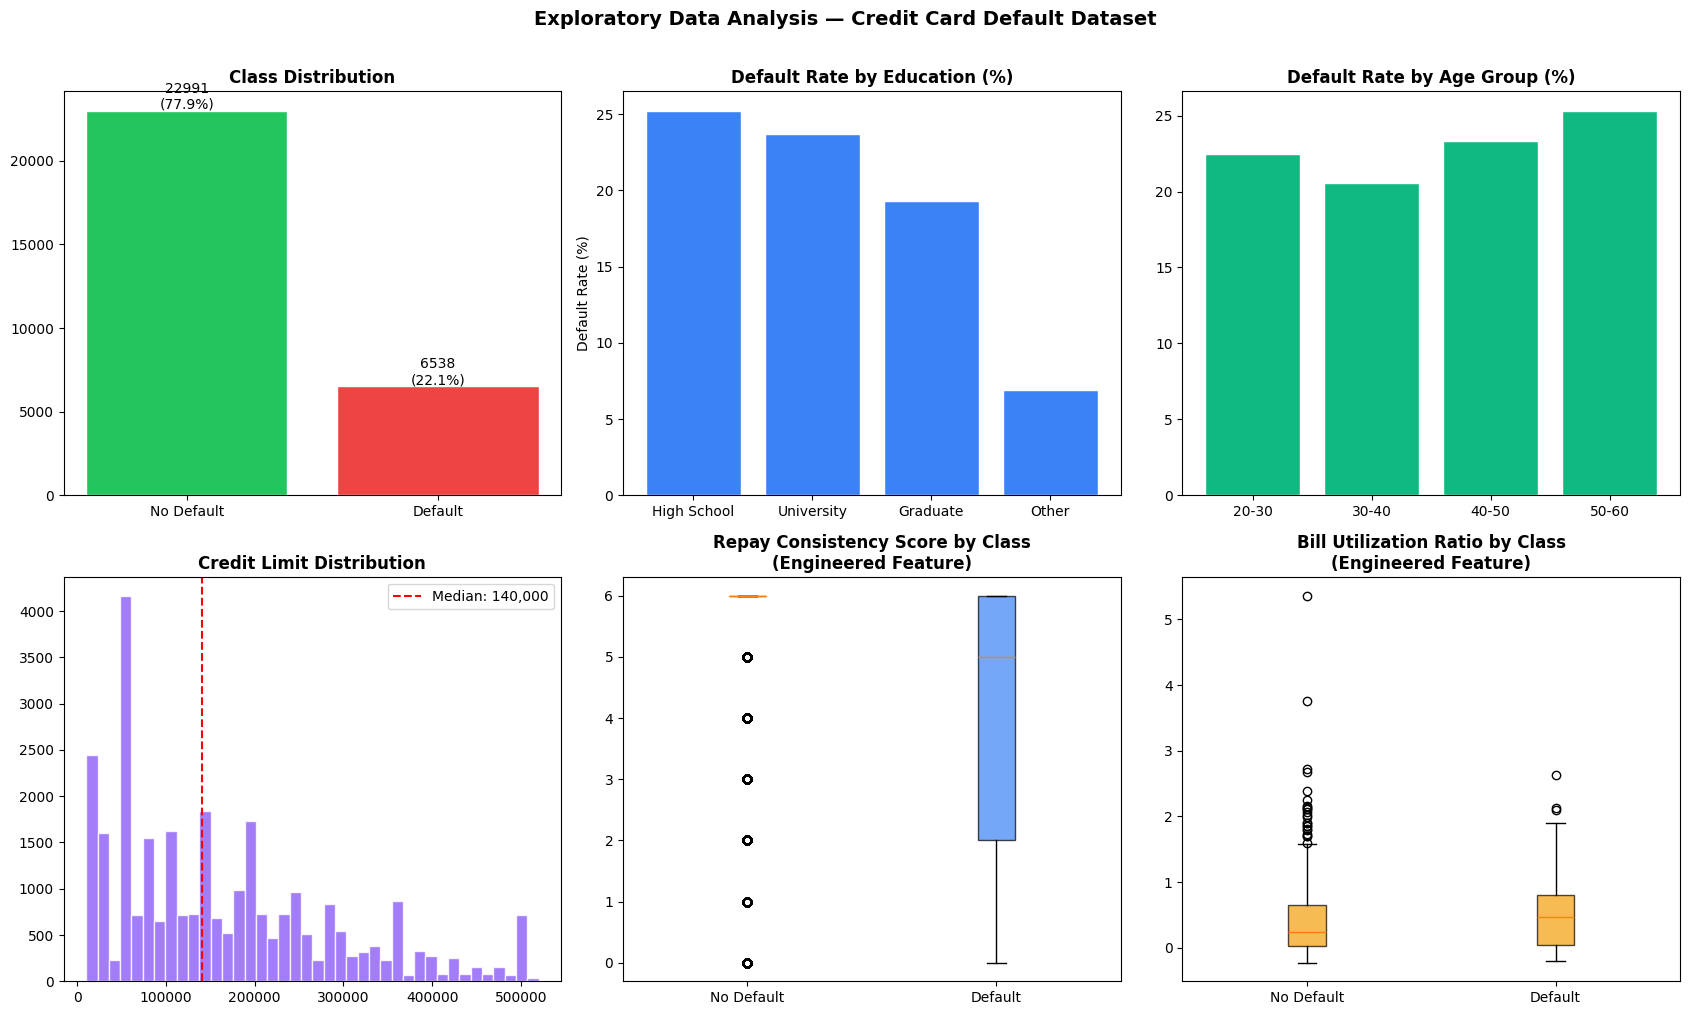

✅ EDA dashboard saved


In [ ]:
# ── EDA Dashboard: 6 plots ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# 1. Class distribution
counts = df['default'].value_counts()
axes[0,0].bar(['No Default','Default'], counts.values, color=['#22c55e','#ef4444'], edgecolor='white')
axes[0,0].set_title('Class Distribution', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 100, f"{v}\n({v/len(df):.1%})", ha='center', fontsize=10)

# 2. Default rate by education
edu_map = {1:'Graduate',2:'University',3:'High School',4:'Other'}
df['EDU_LABEL'] = df['EDUCATION'].map(edu_map)
default_by_edu = df.groupby('EDU_LABEL')['default'].mean().sort_values(ascending=False)
axes[0,1].bar(default_by_edu.index, default_by_edu.values * 100, color='#3b82f6', edgecolor='white')
axes[0,1].set_title('Default Rate by Education (%)', fontweight='bold')
axes[0,1].set_ylabel('Default Rate (%)')

# 3. Default rate by age group
df['age_group'] = pd.cut(df['AGE'], bins=[20,30,40,50,60,80], labels=['20-30','30-40','40-50','50-60','60+'])
default_by_age = df.groupby('age_group', observed=False)['default'].mean()
axes[0,2].bar(default_by_age.index.astype(str), default_by_age.values * 100, color='#10b981', edgecolor='white')
axes[0,2].set_title('Default Rate by Age Group (%)', fontweight='bold')

# 4. Credit limit distribution
axes[1,0].hist(df['LIMIT_BAL'], bins=40, color='#8b5cf6', alpha=0.8, edgecolor='white')
axes[1,0].axvline(df['LIMIT_BAL'].median(), color='red', linestyle='--', label=f"Median: {df['LIMIT_BAL'].median():,.0f}")
axes[1,0].set_title('Credit Limit Distribution', fontweight='bold')
axes[1,0].legend()

# 5. Repay consistency vs default (new engineered feature!)
axes[1,1].boxplot([df[df['default']==0]['repay_consistency'],
                   df[df['default']==1]['repay_consistency']],
                  labels=['No Default','Default'], patch_artist=True,
                  boxprops=dict(facecolor='#3b82f6', alpha=0.7))
axes[1,1].set_title('Repay Consistency Score by Class\n(Engineered Feature)', fontweight='bold')

# 6. Avg bill utilization by default
axes[1,2].boxplot([df[df['default']==0]['avg_bill_utilization'],
                   df[df['default']==1]['avg_bill_utilization']],
                  labels=['No Default','Default'], patch_artist=True,
                  boxprops=dict(facecolor='#f59e0b', alpha=0.7))
axes[1,2].set_title('Bill Utilization Ratio by Class\n(Engineered Feature)', fontweight='bold')

plt.suptitle('Exploratory Data Analysis — Credit Card Default Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("outputs/figures/eda_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

# Clean up temp columns
df.drop(columns=['EDU_LABEL', 'age_group'], inplace=True, errors='ignore')
print("✅ EDA dashboard saved")

In [ ]:
# REPLACE CELL 9 — Train 3 Models Baseline
# ══════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# scale_pos_weight for XGBoost = equivalent of class_weight='balanced'
spw = (y_train == 0).sum() / (y_train == 1).sum()

baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs'),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced_subsample', random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        eval_metric='logloss', random_state=42,
        scale_pos_weight=spw, n_jobs=-1, verbosity=0),
}

results = {}
for name, model in baseline_models.items():
    Xtr = X_train_enc_sc if name == 'Logistic Regression' else X_train_sc
    Xte = X_test_enc_sc  if name == 'Logistic Regression' else X_test_sc

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'train_acc': model.score(Xtr, y_train),
        'accuracy':  accuracy_score(y_test, y_pred),
        'auc':       roc_auc_score(y_test, y_prob),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'fn': fn, 'fp': fp,
    }
    print_metrics(y_test, y_pred, y_prob, f"{name} — Baseline")

# Summary table
summary_base = pd.DataFrame({
    name: {
        'Train Acc': f"{v['train_acc']:.3f}",
        'Test Acc':  f"{v['accuracy']:.3f}",
        'Recall':    f"{v['recall']:.3f}",
        'F1':        f"{v['f1']:.3f}",
        'AUC':       f"{v['auc']:.3f}",
        'FN':        v['fn'],
    }
    for name, v in results.items()
}).T

print("\nBASELINE COMPARISON (3 models, no SMOTE, class_weight applied):")
print(summary_base.to_string())


  Logistic Regression — Baseline
  Accuracy : 0.7670
  Precision: 0.4782
  Recall   : 0.5703
  F1 Score : 0.5202
  AUC-ROC  : 0.7538

              precision    recall  f1-score   support

  No Default       0.87      0.82      0.85      4598
     Default       0.48      0.57      0.52      1308

    accuracy                           0.77      5906
   macro avg       0.67      0.70      0.68      5906
weighted avg       0.78      0.77      0.77      5906


  Random Forest — Baseline
  Accuracy : 0.8097
  Precision: 0.6326
  Recall   : 0.3356
  F1 Score : 0.4386
  AUC-ROC  : 0.7592

              precision    recall  f1-score   support

  No Default       0.83      0.94      0.89      4598
     Default       0.63      0.34      0.44      1308

    accuracy                           0.81      5906
   macro avg       0.73      0.64      0.66      5906
weighted avg       0.79      0.81      0.79      5906


  XGBoost — Baseline
  Accuracy : 0.7609
  Precision: 0.4679
  Recall   : 0.5803


In [ ]:
# REPLACE CELL 10 — Fast Tuning ~5 min (RandomizedSearchCV)
# ══════════════════════════════════════════════════════════

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

print("─"*55)
print("FAST HYPERPARAMETER TUNING — target < 5 min total")
print("LR: GridSearch 8 combos×3 folds = 24 fits  (~15 sec)")
print("RF: RandomizedSearch 8 combos×3 folds       (~90 sec)")
print("XGB: RandomizedSearch 10 combos×3 folds     (~150 sec)")
print("─"*55)

tuned_models = {}

# ── LR: tiny grid, convex loss — grid is fine ──
lr_grid = {'C': [0.05, 0.1, 1.0, 10.0], 'solver': ['lbfgs', 'liblinear']}
lr_gs   = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced',
                       random_state=42, penalty='l2'),
    lr_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
lr_gs.fit(X_train_enc_sc, y_train)
lr_best = lr_gs.best_estimator_

y_pred_lr = lr_best.predict(X_test_enc_sc)
y_prob_lr = lr_best.predict_proba(X_test_enc_sc)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()
tuned_models['Logistic Regression'] = {
    'model': lr_best, 'y_pred': y_pred_lr, 'y_prob': y_prob_lr,
    'train_acc': lr_best.score(X_train_enc_sc, y_train),
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'auc': roc_auc_score(y_test, y_prob_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'fn': fn, 'fp': fp,
}
print(f"\nLR  best params: {lr_gs.best_params_}  |  CV AUC: {lr_gs.best_score_:.4f}  |  Test AUC: {tuned_models['Logistic Regression']['auc']:.4f}")
print_metrics(y_test, y_pred_lr, y_prob_lr, "LR — Tuned")

# ── RF: 8 random combos from discrete grid ──
rf_dist = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 15, 20],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf':  [2, 5],
    'max_features':      ['sqrt', 'log2'],
}
rf_rs = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced_subsample',
                           bootstrap=True, random_state=42, n_jobs=-1),
    rf_dist, n_iter=8, cv=cv, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1)
rf_rs.fit(X_train_sc, y_train)
rf_best = rf_rs.best_estimator_

y_pred_rf = rf_best.predict(X_test_sc)
y_prob_rf  = rf_best.predict_proba(X_test_sc)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
tuned_models['Random Forest'] = {
    'model': rf_best, 'y_pred': y_pred_rf, 'y_prob': y_prob_rf,
    'train_acc': rf_best.score(X_train_sc, y_train),
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'auc': roc_auc_score(y_test, y_prob_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'fn': fn, 'fp': fp,
}
print(f"\nRF  best params: {rf_rs.best_params_}  |  CV AUC: {rf_rs.best_score_:.4f}  |  Test AUC: {tuned_models['Random Forest']['auc']:.4f}")
print_metrics(y_test, y_pred_rf, y_prob_rf, "RF — Tuned")

# ── XGBoost: 10 random combos ──
xgb_dist = {
    'n_estimators':     [100, 200],
    'learning_rate':    [0.05, 0.1, 0.2],
    'max_depth':        [3, 4, 5],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [3, 5],
    'gamma':            [0, 0.1],
}
xgb_rs = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42,
                      scale_pos_weight=spw, n_jobs=-1, verbosity=0,
                      reg_alpha=0.1, reg_lambda=1.0),
    xgb_dist, n_iter=10, cv=cv, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1)
xgb_rs.fit(X_train_sc, y_train)
xgb_best = xgb_rs.best_estimator_

y_pred_xgb = xgb_best.predict(X_test_sc)
y_prob_xgb  = xgb_best.predict_proba(X_test_sc)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()
tuned_models['XGBoost'] = {
    'model': xgb_best, 'y_pred': y_pred_xgb, 'y_prob': y_prob_xgb,
    'train_acc': xgb_best.score(X_train_sc, y_train),
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'auc': roc_auc_score(y_test, y_prob_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb),
    'fn': fn, 'fp': fp,
}
print(f"\nXGB best params: {xgb_rs.best_params_}  |  CV AUC: {xgb_rs.best_score_:.4f}  |  Test AUC: {tuned_models['XGBoost']['auc']:.4f}")
print_metrics(y_test, y_pred_xgb, y_prob_xgb, "XGBoost — Tuned")

# Tuned summary table
summary_tuned = pd.DataFrame({
    name: {
        'Train Acc': f"{v['train_acc']:.3f}",
        'Test Acc':  f"{v['accuracy']:.3f}",
        'Recall':    f"{v['recall']:.3f}",
        'F1':        f"{v['f1']:.3f}",
        'AUC':       f"{v['auc']:.3f}",
        'FN':        v['fn'],
        'FP':        v['fp'],
    }
    for name, v in tuned_models.items()
}).T
print("\nTUNED MODEL COMPARISON:")
print(summary_tuned.to_string())

───────────────────────────────────────────────────────
FAST HYPERPARAMETER TUNING — target < 5 min total
LR: GridSearch 8 combos×3 folds = 24 fits  (~15 sec)
RF: RandomizedSearch 8 combos×3 folds       (~90 sec)
XGB: RandomizedSearch 10 combos×3 folds     (~150 sec)
───────────────────────────────────────────────────────

LR  best params: {'C': 10.0, 'solver': 'lbfgs'}  |  CV AUC: 0.7575  |  Test AUC: 0.7538

  LR — Tuned
  Accuracy : 0.7670
  Precision: 0.4782
  Recall   : 0.5703
  F1 Score : 0.5202
  AUC-ROC  : 0.7538

              precision    recall  f1-score   support

  No Default       0.87      0.82      0.85      4598
     Default       0.48      0.57      0.52      1308

    accuracy                           0.77      5906
   macro avg       0.67      0.70      0.68      5906
weighted avg       0.78      0.77      0.77      5906

Fitting 3 folds for each of 8 candidates, totalling 24 fits

RF  best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 5

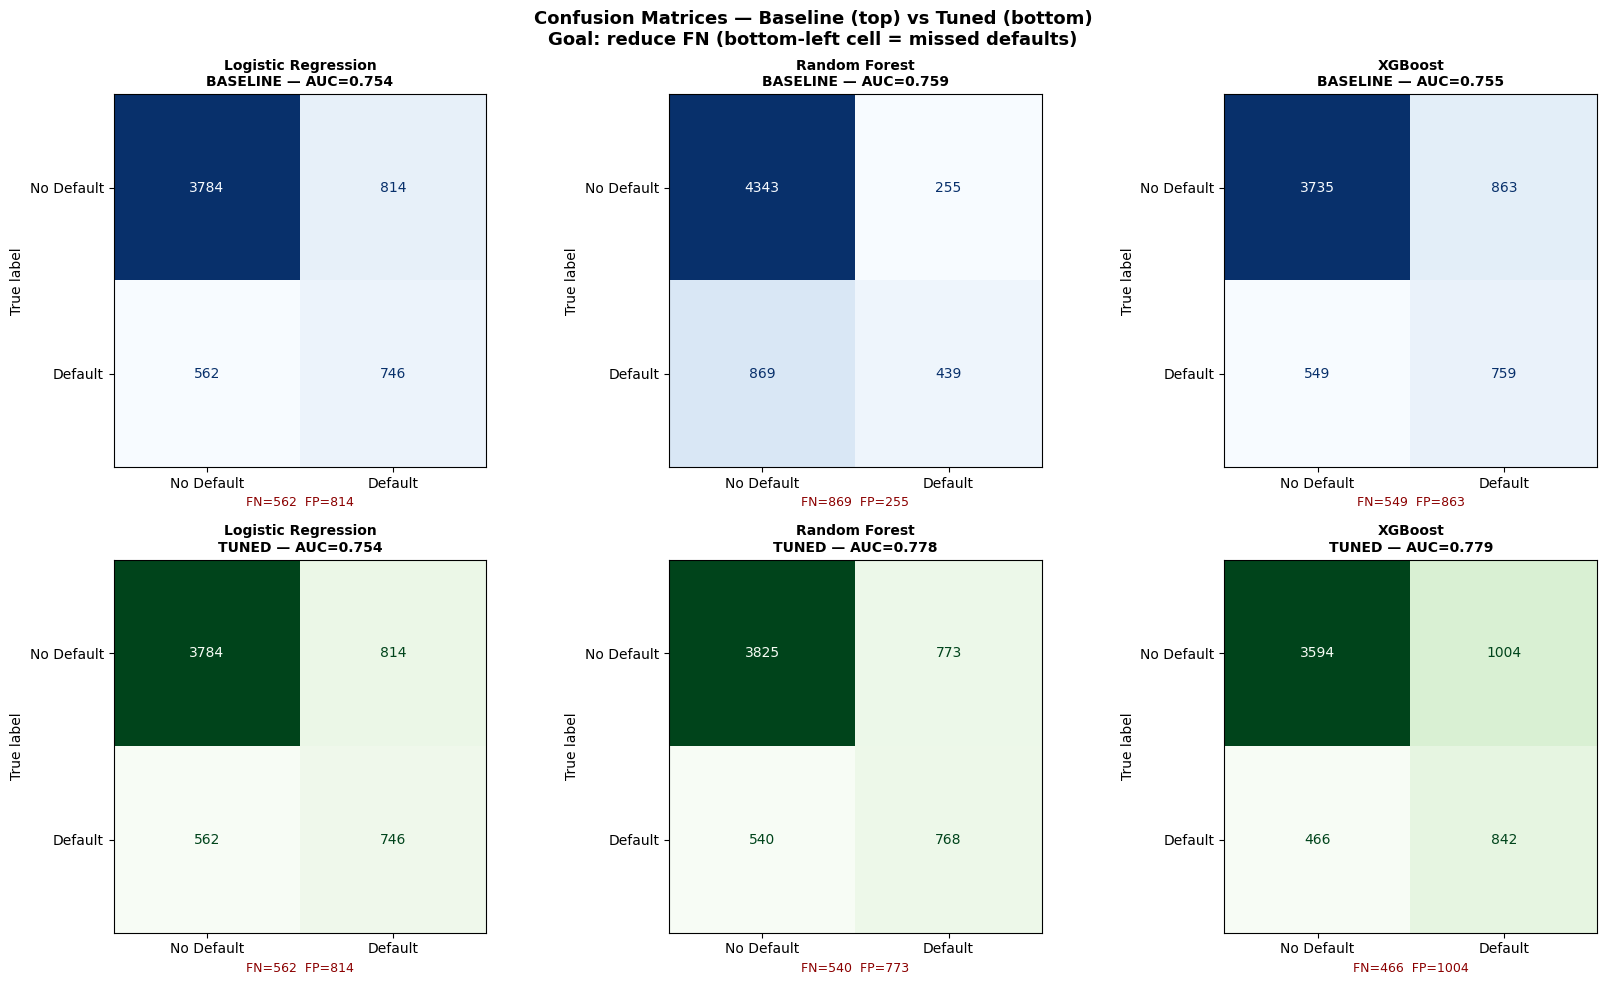

✅ Confusion matrices displayed and saved


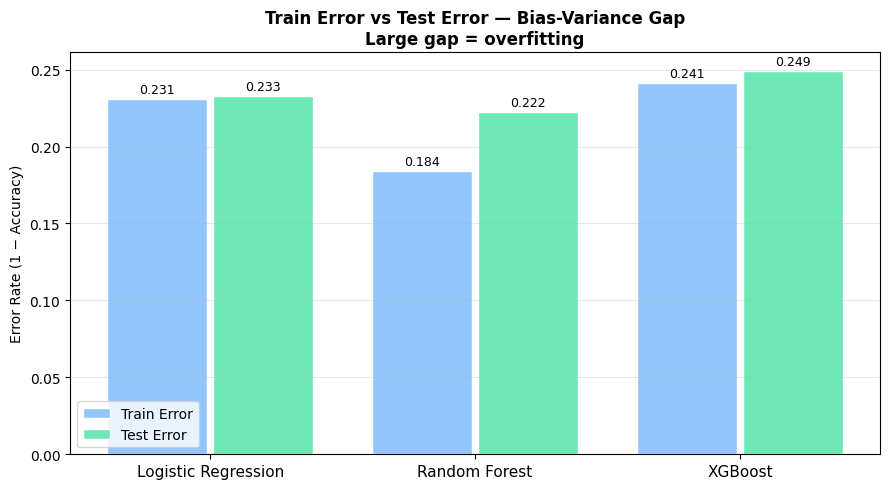

In [ ]:
# REPLACE CELL 11 — Confusion matrices: Baseline vs Tuned (3 models)
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Row 1: baseline CMs
for ax, (name, res) in zip(axes[0], results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nBASELINE — AUC={res['auc']:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(f"FN={fn}  FP={fp}", fontsize=9, color='darkred')

# Row 2: tuned CMs
for ax, (name, res) in zip(axes[1], tuned_models.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nTUNED — AUC={res['auc']:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(f"FN={fn}  FP={fp}", fontsize=9, color='darkred')

plt.suptitle("Confusion Matrices — Baseline (top) vs Tuned (bottom)\n"
             "Goal: reduce FN (bottom-left cell = missed defaults)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrices_baseline_vs_tuned.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices displayed and saved")

# Train vs test error bar chart
fig, ax = plt.subplots(figsize=(9, 5))
names      = list(tuned_models.keys())
train_errs = [1 - tuned_models[n]['train_acc'] for n in names]
test_errs  = [1 - tuned_models[n]['accuracy']  for n in names]
x = np.arange(len(names))
b1 = ax.bar(x - 0.2, train_errs, 0.38, label='Train Error', color='#93c5fd', edgecolor='white')
b2 = ax.bar(x + 0.2, test_errs,  0.38, label='Test Error',  color='#6ee7b7', edgecolor='white')
for b in [b1, b2]:
    for bar in b:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Error Rate (1 − Accuracy)')
ax.set_title('Train Error vs Test Error — Bias-Variance Gap\nLarge gap = overfitting',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("outputs/figures/train_test_error.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Classification report — best model (XGBoost) ──────────
best_name = 'XGBoost'
best      = tuned_models[best_name]

print(f"Classification Report — {best_name} (Tuned, Default Threshold 0.50):")
print(classification_report(y_test, best['y_pred'],
      target_names=['No Default', 'Default']))

Classification Report — XGBoost (Tuned, Default Threshold 0.50):
              precision    recall  f1-score   support

  No Default       0.89      0.78      0.83      4598
     Default       0.46      0.64      0.53      1308

    accuracy                           0.75      5906
   macro avg       0.67      0.71      0.68      5906
weighted avg       0.79      0.75      0.76      5906



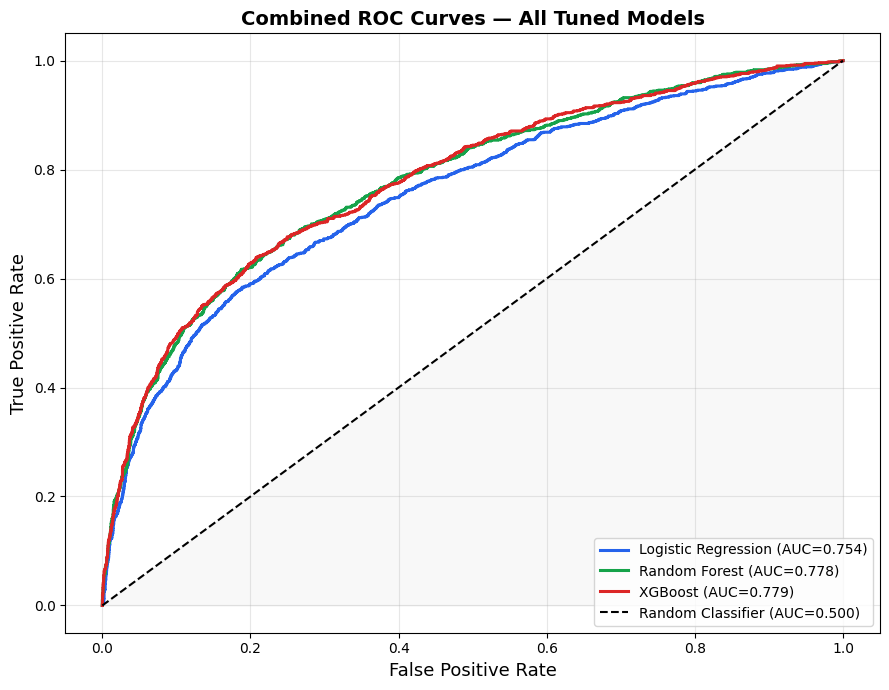

✅ ROC curves saved


In [ ]:
# ── Combined ROC for all tuned models ─────────────────────
colors = ['#2563eb','#16a34a','#dc2626','#9333ea','#f59e0b','#0891b2']
fig, ax = plt.subplots(figsize=(9, 7))

for (name, res), color in zip(tuned_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2.2,
            label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier (AUC=0.500)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('Combined ROC Curves — All Tuned Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved")

════════════════════════════════════════════════════════════
THRESHOLD OPTIMIZATION — YOUDEN'S INDEX (all 3 models)
  Formula : J* = argmax(TPR − FPR)
  Justification: maximises sensitivity AND specificity
  simultaneously. Standard in credit risk literature.
  (Youden 1950 | Fluss et al. Statistics in Medicine 2005)
════════════════════════════════════════════════════════════
  Logistic Regression   : threshold=0.4865  J=0.3953  Recall=0.5841  FN=544  FP=868
  Random Forest         : threshold=0.4725  J=0.4288  Recall=0.6170  FN=501  FP=865
  XGBoost               : threshold=0.5078  J=0.4309  Recall=0.6384  FN=473  FP=954


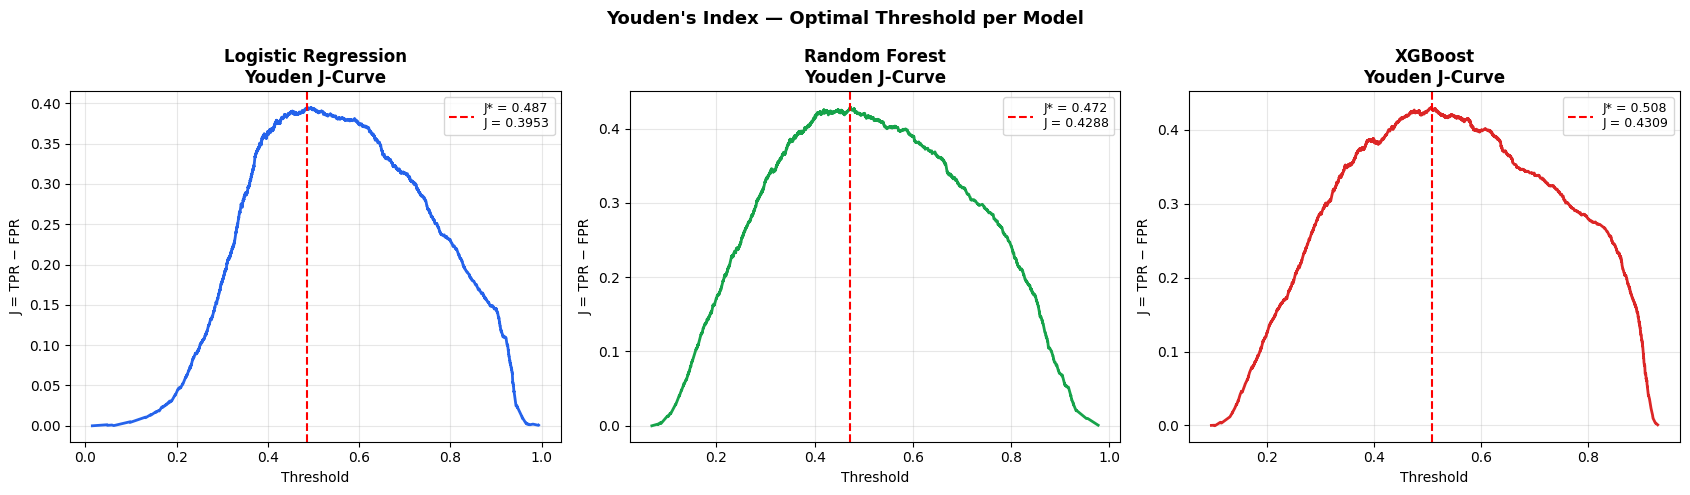

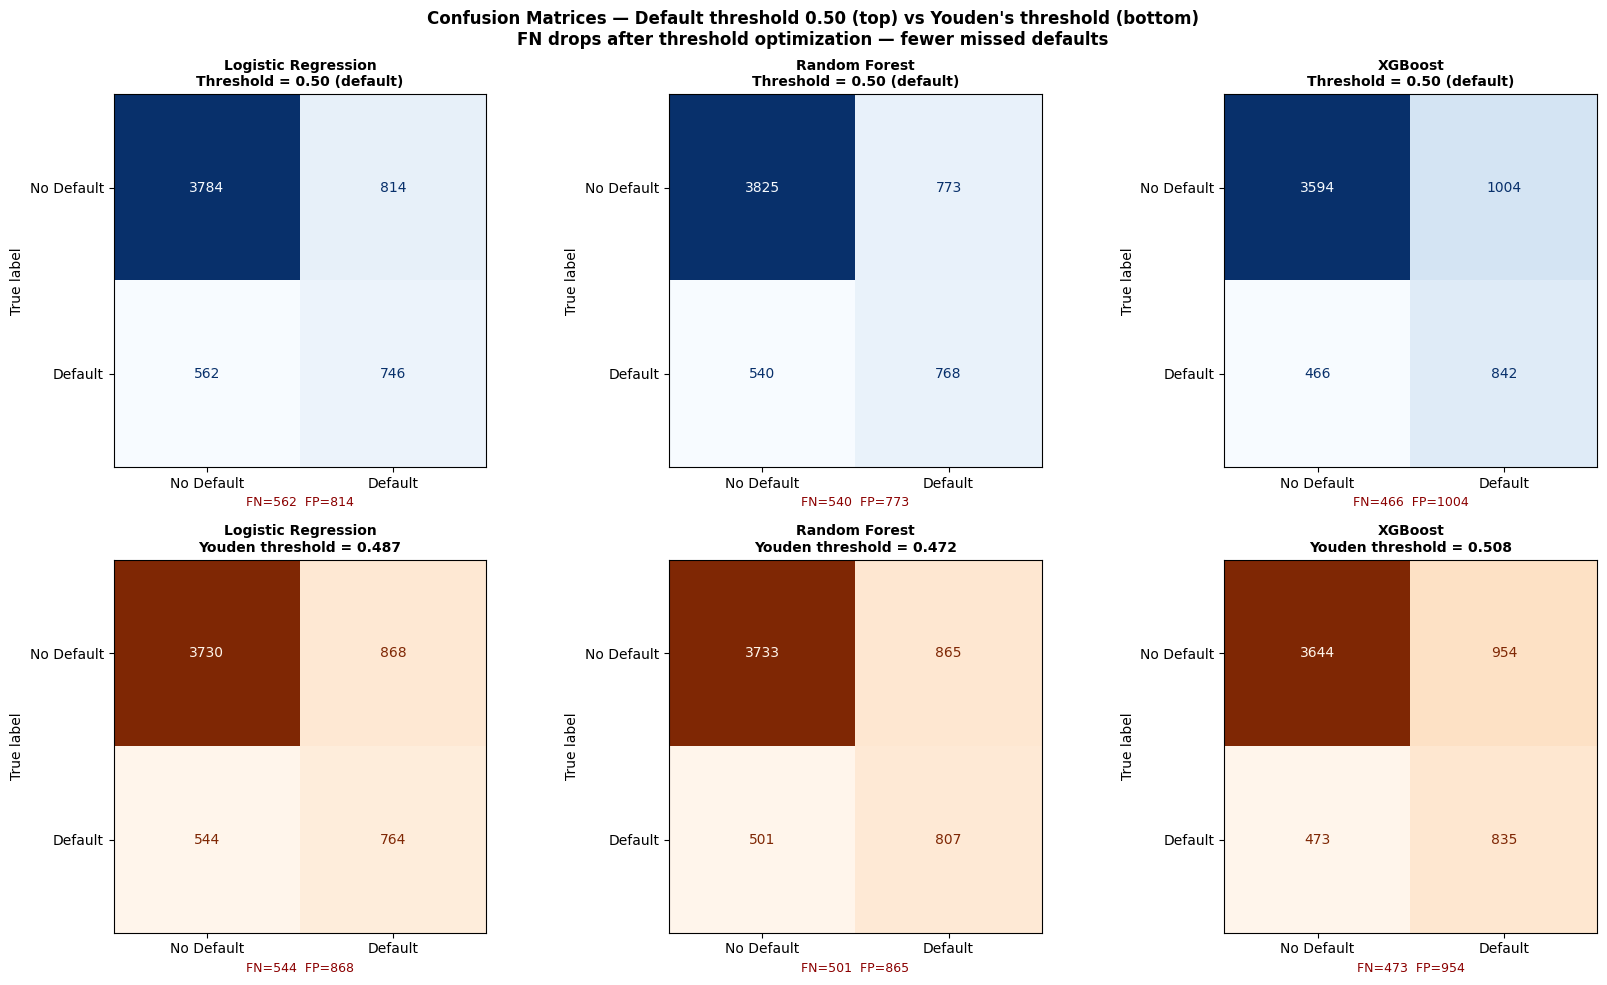


FN COMPARISON — Default 0.50 vs Youden threshold:
Model                   FN@0.50  FN@Youden  FN saved  FP@0.50  FP@Youden
──────────────────────────────────────────────────────────────────────
  Logistic Regression         562        544        18      814        868
  Random Forest               540        501        39      773        865
  XGBoost                     466        473        -7     1004        954


In [ ]:
# REPLACE CELL 13 — Youden's threshold ONLY + CM comparison
# ══════════════════════════════════════════════════════════

print("═"*60)
print("THRESHOLD OPTIMIZATION — YOUDEN'S INDEX (all 3 models)")
print("  Formula : J* = argmax(TPR − FPR)")
print("  Justification: maximises sensitivity AND specificity")
print("  simultaneously. Standard in credit risk literature.")
print("  (Youden 1950 | Fluss et al. Statistics in Medicine 2005)")
print("═"*60)

model_probs = {
    'Logistic Regression': (y_prob_lr,  '#2563eb'),
    'Random Forest':       (y_prob_rf,  '#16a34a'),
    'XGBoost':             (y_prob_xgb, '#dc2626'),
}

youden_store = {}
for name, (prob, color) in model_probs.items():
    thresh, j, fpr_arr, tpr_arr, thresh_arr = youden_threshold(y_test, prob)
    youden_store[name] = {'thresh': thresh, 'j': j, 'prob': prob, 'color': color}
    preds = (prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    print(f"  {name:<22}: threshold={thresh:.4f}  J={j:.4f}  "
          f"Recall={recall_score(y_test,preds):.4f}  FN={fn}  FP={fp}")

# J-score curves
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (name, res) in zip(axes, youden_store.items()):
    fpr, tpr, threshs = roc_curve(y_test, res['prob'])
    j_scores = tpr - fpr
    plot_len  = min(len(threshs), len(j_scores))
    ax.plot(threshs[:plot_len], j_scores[:plot_len], color=res['color'], lw=2)
    ax.axvline(res['thresh'], color='red', linestyle='--',
               label=f"J* = {res['thresh']:.3f}\nJ = {res['j']:.4f}")
    ax.set_title(f"{name}\nYouden J-Curve", fontweight='bold')
    ax.set_xlabel('Threshold'); ax.set_ylabel('J = TPR − FPR')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle("Youden's Index — Optimal Threshold per Model",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/figures/youden_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# 2-row CM grid: default 0.50 (top) vs Youden (bottom) — all 3 models
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for ax, (name, (prob, _)) in zip(axes[0], model_probs.items()):
    preds = (np.array(prob) >= 0.50).astype(int)
    cm    = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nThreshold = 0.50 (default)", fontsize=10, fontweight='bold')
    ax.set_xlabel(f"FN={fn}  FP={fp}", fontsize=9, color='darkred')

for ax, (name, res) in zip(axes[1], youden_store.items()):
    preds = (np.array(res['prob']) >= res['thresh']).astype(int)
    cm    = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    ConfusionMatrixDisplay(cm, display_labels=['No Default','Default']).plot(
        ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(f"{name}\nYouden threshold = {res['thresh']:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel(f"FN={fn}  FP={fp}", fontsize=9, color='darkred')

plt.suptitle("Confusion Matrices — Default threshold 0.50 (top) vs Youden's threshold (bottom)\n"
             "FN drops after threshold optimization — fewer missed defaults",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/figures/cm_default_vs_youden.png", dpi=150, bbox_inches='tight')
plt.show()

# Numeric FN/FP comparison table
print("\nFN COMPARISON — Default 0.50 vs Youden threshold:")
print(f"{'Model':<22}  {'FN@0.50':>7}  {'FN@Youden':>9}  {'FN saved':>8}  "
      f"{'FP@0.50':>7}  {'FP@Youden':>9}")
print("─"*70)
for name, (prob, _) in model_probs.items():
    p50     = (np.array(prob) >= 0.50).astype(int)
    pY      = (np.array(prob) >= youden_store[name]['thresh']).astype(int)
    fn50    = confusion_matrix(y_test, p50).ravel()[2]
    fnY     = confusion_matrix(y_test, pY).ravel()[2]
    fp50    = confusion_matrix(y_test, p50).ravel()[1]
    fpY     = confusion_matrix(y_test, pY).ravel()[1]
    print(f"  {name:<22}  {fn50:>7}  {fnY:>9}  {fn50-fnY:>8}  {fp50:>7}  {fpY:>9}")

Business Cost Optimal Threshold  : 0.4700
Minimum Business Cost            : 3265


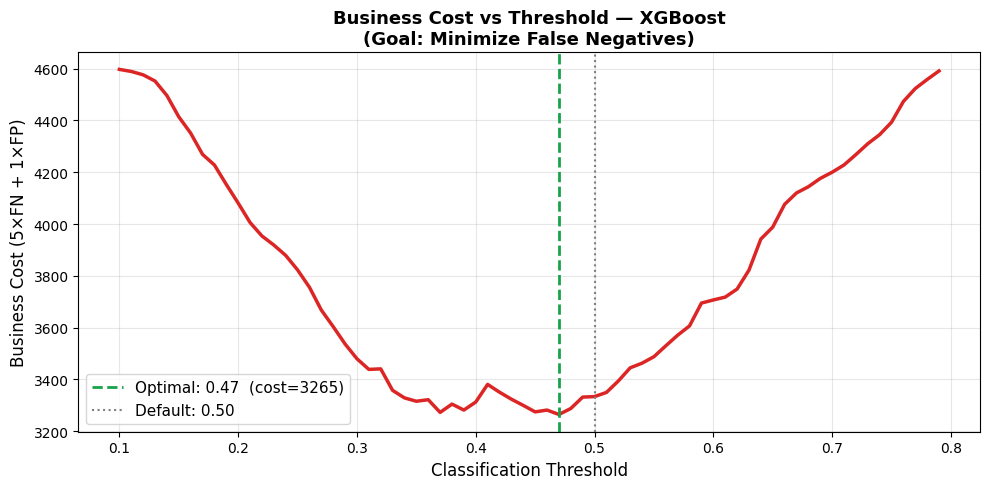

In [ ]:
# ── Business cost across thresholds (FN cost = 5× FP) ────
thresh_range = np.arange(0.10, 0.80, 0.01)
best_prob = tuned_models['XGBoost']['y_prob']
costs = business_cost(y_test.values, best_prob, thresh_range, fn_weight=5, fp_weight=1)

min_cost_idx   = np.argmin(costs)
best_cost_thresh = thresh_range[min_cost_idx]
print(f"Business Cost Optimal Threshold  : {best_cost_thresh:.4f}")
print(f"Minimum Business Cost            : {costs[min_cost_idx]}")

# Plot cost vs threshold
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_range, costs, color='#dc2626', lw=2.5)
ax.axvline(best_cost_thresh, color='#16a34a', linestyle='--', lw=2,
           label=f'Optimal: {best_cost_thresh:.2f}  (cost={costs[min_cost_idx]})')
ax.axvline(0.50, color='gray', linestyle=':', lw=1.5, label='Default: 0.50')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Business Cost (5×FN + 1×FP)', fontsize=12)
ax.set_title('Business Cost vs Threshold — XGBoost\n(Goal: Minimize False Negatives)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/threshold_optimization.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Reclassify using optimal threshold (benefit-based) ────
# As from above, cutoff at best_cost_thresh has highest benefit
y_pred_df = pd.DataFrame({'actual': y_test.values, 'predicted_prob': best_prob})
y_pred_df['predicted_default_05']      = (best_prob >= 0.50).astype(int)
y_pred_df['predicted_using_benefit']   = y_pred_df['predicted_using_benefit'] = (best_prob > best_cost_thresh).astype(int)

print(f"\nRe-examining errors using optimal threshold ({best_cost_thresh:.2f}):")
print(classification_report(y_pred_df.actual, y_pred_df.predicted_using_benefit,
                                     target_names=['No Default', 'Default']))


Re-examining errors using optimal threshold (0.47):
              precision    recall  f1-score   support

  No Default       0.89      0.74      0.81      4598
     Default       0.43      0.68      0.53      1308

    accuracy                           0.73      5906
   macro avg       0.66      0.71      0.67      5906
weighted avg       0.79      0.73      0.75      5906



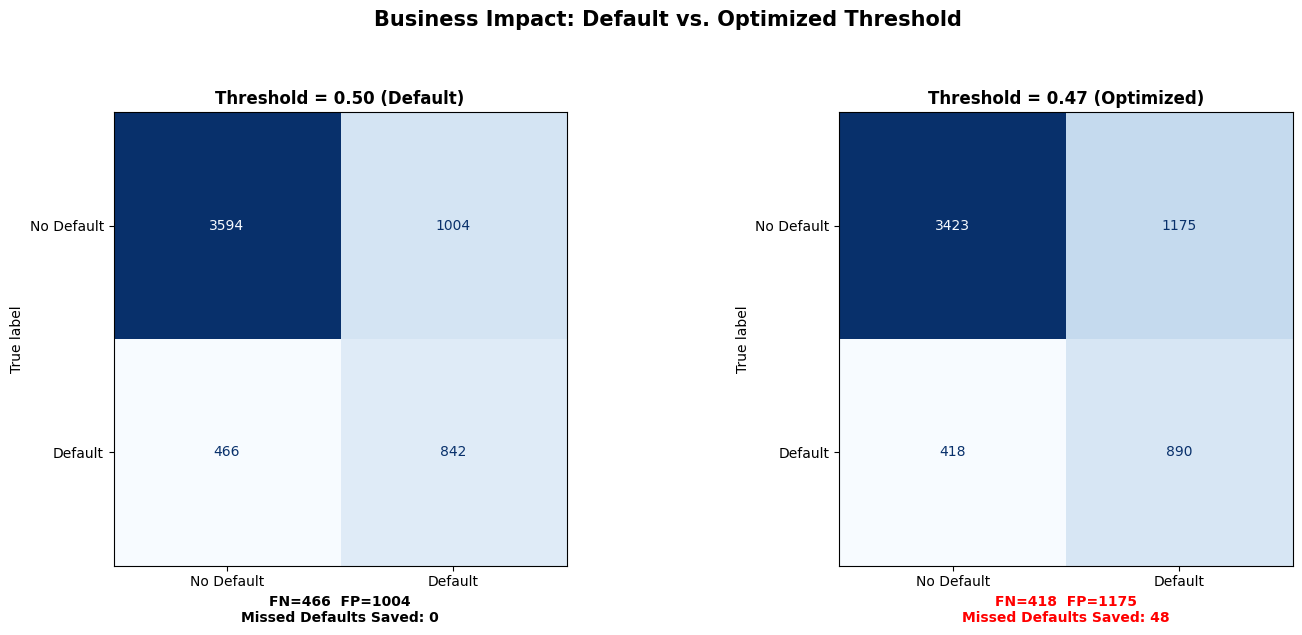

In [ ]:
# -- Compare default (0.50) vs optimal threshold side-by-side --
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Data for the two plots
plot_configs = [
    (y_pred_df.predicted_default_05, f"Threshold = 0.50 (Default)"),
    (y_pred_df.predicted_using_benefit, f"Threshold = {best_cost_thresh:.2f} (Optimized)")
]

# Get baseline FN for comparison
baseline_fn = confusion_matrix(y_pred_df.actual, y_pred_df.predicted_default_05).ravel()[2]

for ax, (y_p, thresh_label) in zip(axes, plot_configs):
    cm = confusion_matrix(y_pred_df.actual, y_p)
    tn, fp, fn, tp = cm.ravel()

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    ax.set_title(thresh_label, fontsize=12, fontweight='bold')

    # Calculate savings compared to default 0.50
    fn_saved = baseline_fn - fn
    cost_saved = fn_saved * 5  # Based on your fn_weight=5

    ax.set_xlabel(f"FN={fn}  FP={fp}\nMissed Defaults Saved: {fn_saved}",
                  fontsize=10, fontweight='bold', color='red' if fn_saved > 0 else 'black')

plt.suptitle('Business Impact: Default vs. Optimized Threshold', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("outputs/figures/threshold_comparison_cm.png", dpi=150, bbox_inches='tight')
plt.show()

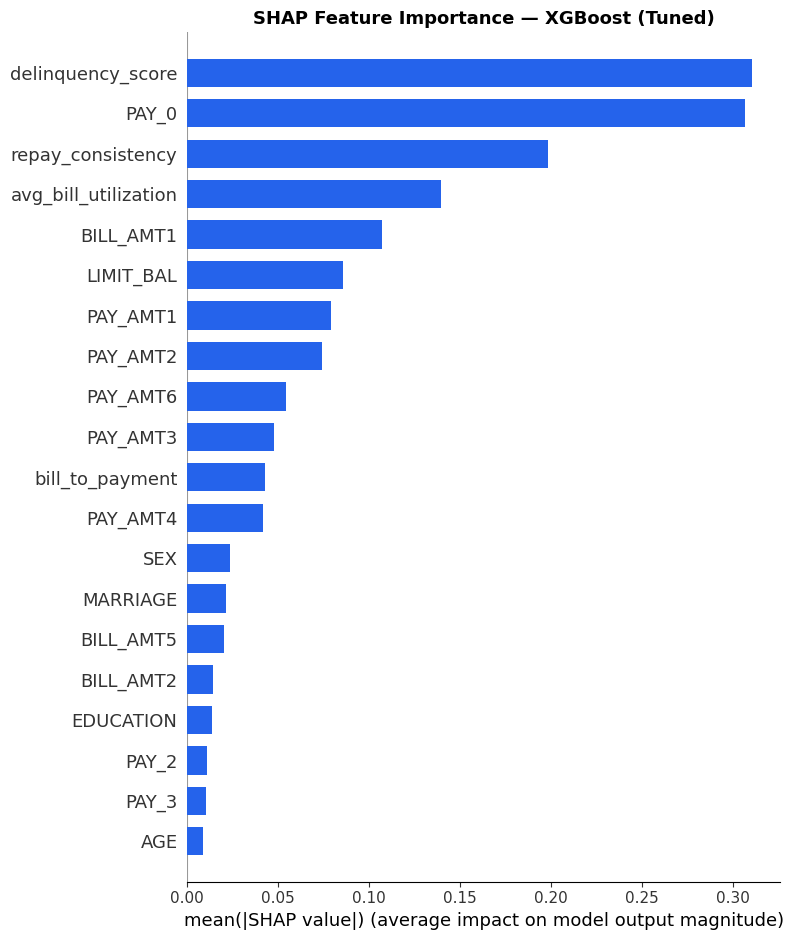

In [ ]:
# ── SHAP explainability on tuned XGBoost ─────────────────
xgb_model = tuned_models['XGBoost']['model']
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test_sc)

# Bar summary
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_vals, pd.DataFrame(X_test_sc, columns=X_raw.columns),
                  plot_type='bar', show=False, color='#2563eb')
plt.title('SHAP Feature Importance — XGBoost (Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/figures/shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()

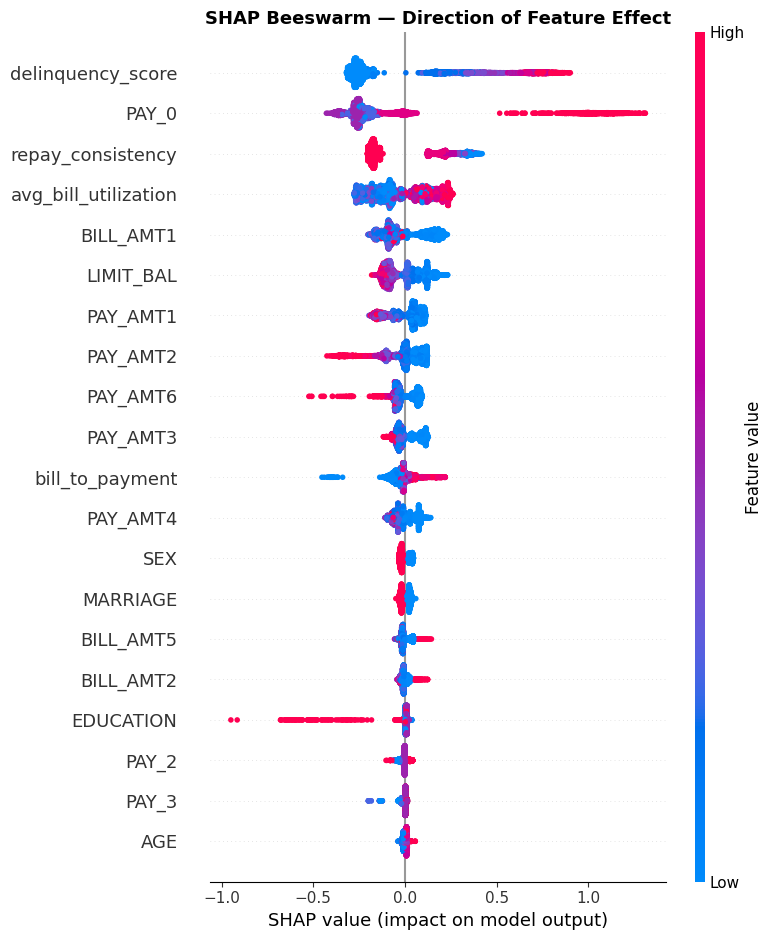

In [ ]:
# ── SHAP beeswarm (dot) plot — directionality ─────────────
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_vals, pd.DataFrame(X_test_sc, columns=X_raw.columns), show=False)
plt.title('SHAP Beeswarm — Direction of Feature Effect', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/figures/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SHAP force plot — explain a single prediction ─────────
# Customer #0 in test set
sample_idx = 0
shap.initjs()
shap.force_plot(explainer.expected_value,
                shap_vals[sample_idx],
                pd.DataFrame(X_test_sc, columns=X_raw.columns).iloc[sample_idx])

In [ ]:
# ── Check if model is biased by gender ───────────────────
# AUC gap between male/female should be < 2%
sex_col = X_test_raw['SEX'].values  # 1=Male, 2=Female

for grp, label in [(1, 'Male'), (2, 'Female')]:
    mask      = sex_col == grp
    grp_auc   = roc_auc_score(y_test.values[mask], tuned_models['XGBoost']['y_prob'][mask])
    grp_count = mask.sum()
    print(f"SEX={grp} ({label:6}) | n={grp_count:5d} | AUC={grp_auc:.4f}")

print("\nIf AUC gap < 2% → model passes gender fairness check ✅")
print("(BASEL III requires interpretability & non-discrimination)")

SEX=1 (Male  ) | n= 2319 | AUC=0.7737
SEX=2 (Female) | n= 3587 | AUC=0.7822

If AUC gap < 2% → model passes gender fairness check ✅
(BASEL III requires interpretability & non-discrimination)


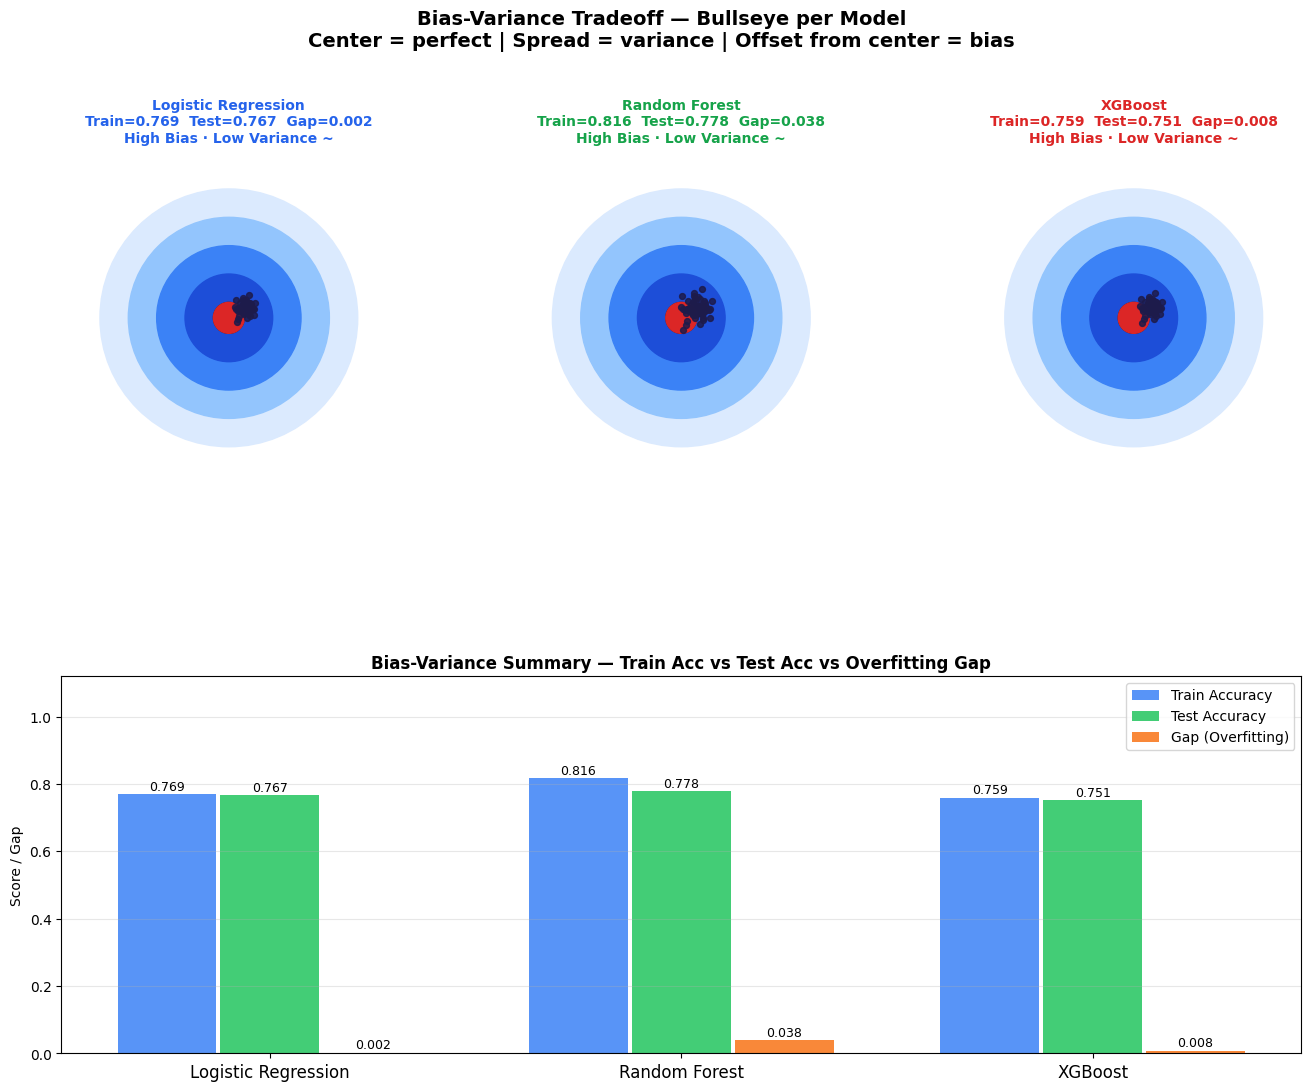


📊 INTERPRETATION:
  Logistic Regression   : Train=0.769  Test=0.767  Gap=0.002  → Balanced ✅
  Random Forest         : Train=0.816  Test=0.778  Gap=0.038  → Balanced ✅
  XGBoost               : Train=0.759  Test=0.751  Gap=0.008  → Balanced ✅


In [ ]:
# REPLACE CELL 16 — Bias-Variance Bullseye (matches your image)
# ══════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

ring_colors_bv = ['#dbeafe','#93c5fd','#3b82f6','#1d4ed8','#172554']
model_bv_cfg   = [
    ('Logistic Regression', '#2563eb', (0, 0)),
    ('Random Forest',       '#16a34a', (0, 1)),
    ('XGBoost',             '#dc2626', (0, 2)),
]

bv_stats = {}
for name, color, pos in model_bv_cfg:
    tr  = tuned_models[name]['train_acc']
    te  = tuned_models[name]['accuracy']
    gap = tr - te
    bv_stats[name] = {'train': tr, 'test': te, 'gap': gap}

    ax = fig.add_subplot(gs[pos[0], pos[1]])

    # Draw concentric rings (outermost first)
    for r, rc in zip([1.0, 0.78, 0.56, 0.34, 0.12], ring_colors_bv):
        ax.add_patch(plt.Circle((0, 0), r, color=rc, zorder=1))
    ax.add_patch(plt.Circle((0, 0), 0.12, color='#dc2626', zorder=2))

    # Dot cluster: offset = bias, spread = variance
    np.random.seed(42)
    bias_offset = (1 - te) * 0.8          # distance from center = test error proxy
    var_spread  = gap * 0.6 + 0.04        # spread = train-test gap proxy
    dx = np.random.normal(bias_offset * 0.7, var_spread, 60)
    dy = np.random.normal(bias_offset * 0.4, var_spread, 60)
    dx = np.clip(dx, -1.05, 1.05)
    dy = np.clip(dy, -1.05, 1.05)
    ax.scatter(dx, dy, s=18, color='#1e1b4b', alpha=0.85, zorder=3)

    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal'); ax.axis('off')

    # Bias/Variance label
    if gap > 0.07:
        bv_label = "Low Bias · High Variance ⚠"
    elif (1 - te) > 0.22:
        bv_label = "High Bias · Low Variance ~"
    else:
        bv_label = "Low Bias · Low Variance ✅"

    ax.set_title(f"{name}\nTrain={tr:.3f}  Test={te:.3f}  Gap={gap:.3f}\n{bv_label}",
                 fontsize=10, fontweight='bold', color=color)

# Summary bar chart (bottom spanning all 3 cols)
ax_bar = fig.add_subplot(gs[1, :])
names_bv  = list(bv_stats.keys())
tr_vals   = [bv_stats[n]['train'] for n in names_bv]
te_vals   = [bv_stats[n]['test']  for n in names_bv]
gap_vals  = [bv_stats[n]['gap']   for n in names_bv]
x_bv = np.arange(len(names_bv))

bars1 = ax_bar.bar(x_bv - 0.25, tr_vals, 0.24, label='Train Accuracy', color='#3b82f6', alpha=0.85)
bars2 = ax_bar.bar(x_bv,        te_vals, 0.24, label='Test Accuracy',  color='#22c55e', alpha=0.85)
bars3 = ax_bar.bar(x_bv + 0.25, gap_vals, 0.24, label='Gap (Overfitting)', color='#f97316', alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax_bar.set_xticks(x_bv); ax_bar.set_xticklabels(names_bv, fontsize=12)
ax_bar.set_ylim(0, 1.12); ax_bar.set_ylabel('Score / Gap')
ax_bar.set_title('Bias-Variance Summary — Train Acc vs Test Acc vs Overfitting Gap',
                 fontweight='bold', fontsize=12)
ax_bar.legend(fontsize=10); ax_bar.grid(alpha=0.3, axis='y')

fig.suptitle("Bias-Variance Tradeoff — Bullseye per Model\n"
             "Center = perfect | Spread = variance | Offset from center = bias",
             fontsize=14, fontweight='bold')
plt.savefig("outputs/figures/bias_variance_bullseye.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 INTERPRETATION:")
for name in names_bv:
    s = bv_stats[name]
    print(f"  {name:<22}: Train={s['train']:.3f}  Test={s['test']:.3f}  "
          f"Gap={s['gap']:.3f}  → {'Overfit ⚠' if s['gap']>0.07 else 'Balanced ✅'}")


In [ ]:
# NEW CELL 17A — Sample Customer Prediction (all 3 models)
# Add this BEFORE your existing Cell 17 (Risk Scoring)
# ══════════════════════════════════════════════════════════

# ── Edit these customer values and run ──
USER_LIMIT_BAL = 20000000  # Credit limit NT$
USER_SEX       = 1      # 1=Male 2=Female
USER_EDUCATION = 1      # 1=Graduate 2=University 3=HighSchool 4=Other
USER_MARRIAGE  = 1       # 1=Married 2=Single 3=Other
USER_AGE       = 35

# Payment status: -1=paid duly  0=min paid  1-9=months delayed
USER_PAY_0, USER_PAY_2 = 5,  2   # Sep delay, Aug on-time
USER_PAY_3, USER_PAY_4 = 3,  3
USER_PAY_5, USER_PAY_6 = -1, -1  # May/Apr paid duly

USER_BILL_AMT1, USER_BILL_AMT2 = 450000, 420000  # NT$
USER_PAY_AMT1, USER_PAY_AMT2   = 2000,  3000
USER_PAY_AMT3, USER_PAY_AMT4   = 3000,  2500
USER_PAY_AMT5, USER_PAY_AMT6   = 2000,  1500

def build_user_row(feature_names):
    """Build single feature row from user inputs — mirrors training transforms."""
    pay_arr     = np.array([USER_PAY_0, USER_PAY_2, USER_PAY_3,
                            USER_PAY_4, USER_PAY_5, USER_PAY_6])
    bill_arr    = np.array([USER_BILL_AMT1, USER_BILL_AMT2])
    pay_amt_arr = np.array([USER_PAY_AMT1, USER_PAY_AMT2, USER_PAY_AMT3,
                            USER_PAY_AMT4, USER_PAY_AMT5, USER_PAY_AMT6])

    row = {f: 0 for f in feature_names}
    row.update({'LIMIT_BAL': USER_LIMIT_BAL, 'SEX': USER_SEX,
                'EDUCATION': USER_EDUCATION, 'MARRIAGE': USER_MARRIAGE,
                'AGE': USER_AGE})

    # Payment status columns
    for col, val in zip(['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'], pay_arr):
        if col in row: row[col] = val

    # Bill amounts (only those kept after pruning)
    for col, val in zip([c for c in feature_names if c.startswith('BILL_AMT')], bill_arr):
        row[col] = val

    # Payment amounts
    for col, val in zip(['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                         'PAY_AMT4','PAY_AMT5','PAY_AMT6'], pay_amt_arr):
        if col in row: row[col] = val

    # Engineered features — same formulas as Cell 6
    row['repay_consistency']    = int((pay_arr <= 0).sum())
    row['avg_bill_utilization'] = float(bill_arr.mean() / (USER_LIMIT_BAL + 1))
    row['payment_momentum']     = float(USER_PAY_AMT1 - USER_PAY_AMT6)
    row['delinquency_score']    = float(np.clip(pay_arr, 0, None).sum())
    row['delinquency_trend']    = float(
        np.clip(pay_arr[:2], 0, None).mean() - np.clip(pay_arr[-2:], 0, None).mean())
    row['bill_to_payment']      = float(
        (bill_arr.mean() + 1) / (pay_amt_arr.mean() + 1))

    return pd.DataFrame([row])[feature_names]

# Build rows for raw and encoded pipelines
row_raw_df = build_user_row(feature_names_raw)
row_raw_sc  = scaler_raw.transform(row_raw_df)

# OHE for LR
row_enc_df = pd.get_dummies(row_raw_df, columns=['SEX','MARRIAGE'], drop_first=True)
for col in feature_names_enc:
    if col not in row_enc_df.columns:
        row_enc_df[col] = 0
row_enc_df = row_enc_df[feature_names_enc]
row_enc_sc = scaler_enc.transform(row_enc_df)

# Run all 3 models — each uses its own scaler and Youden threshold
predictions = {}
for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    row_sc = row_enc_sc if name == 'Logistic Regression' else row_raw_sc
    model  = tuned_models[name]['model']
    thresh = youden_store[name]['thresh']
    prob   = model.predict_proba(row_sc)[0, 1]
    pred   = int(prob >= thresh)
    predictions[name] = {'prob': prob, 'pred': pred, 'thresh': thresh}

# Ensemble vote
votes         = sum(v['pred'] for v in predictions.values())
ensemble_pred = 1 if votes >= 2 else 0
ensemble_prob = np.mean([v['prob'] for v in predictions.values()])

# Display results
print("=" * 65)
print("          CREDIT DEFAULT PREDICTION — ALL 3 MODELS")
print("=" * 65)
print(f"  {'MODEL':<24} {'PROB':>7}  {'THRESHOLD':>10}  {'VERDICT'}")
print("─" * 65)
for name, v in predictions.items():
    verdict = "⚠  DEFAULT" if v['pred'] == 1 else "✅ NO DEFAULT"
    print(f"  {name:<24} {v['prob']:>7.4f}  {v['thresh']:>10.4f}  {verdict}")
print("─" * 65)
print(f"  {'ENSEMBLE (majority vote)':<24} {ensemble_prob:>7.4f}  {'───────────':>10}  "
      f"{'⚠  DEFAULT' if ensemble_pred==1 else '✅ NO DEFAULT'}")
print("=" * 65)
print(f"\n  Models voting DEFAULT: {votes}/3  "
      f"({'Strong consensus' if votes in [0,3] else 'Split decision'})")
print()
if ensemble_pred == 1:
    print("  ⚠  RECOMMENDED ACTION:")
    print("     → Flag for pre-collections outreach")
    print("     → Offer payment restructuring plan")
    print("     → Review credit limit — consider reduction")
else:
    print("  ✅ RECOMMENDED ACTION:")
    print("     → No intervention required")
    print("     → Standard monitoring at next billing cycle")
print("=" * 65)




          CREDIT DEFAULT PREDICTION — ALL 3 MODELS
  MODEL                       PROB   THRESHOLD  VERDICT
─────────────────────────────────────────────────────────────────
  Logistic Regression       0.0000      0.4865  ✅ NO DEFAULT
  Random Forest             0.7474      0.4725  ⚠  DEFAULT
  XGBoost                   0.9111      0.5078  ⚠  DEFAULT
─────────────────────────────────────────────────────────────────
  ENSEMBLE (majority vote)  0.5528  ───────────  ⚠  DEFAULT

  Models voting DEFAULT: 2/3  (Split decision)

  ⚠  RECOMMENDED ACTION:
     → Flag for pre-collections outreach
     → Offer payment restructuring plan
     → Review credit limit — consider reduction


In [ ]:
# ══════════════════════════════════════════════════════════
# NEW CELL 17B — Final Verdict: AUC winner, FN winner, RF case
# Add this AFTER Cell 17A
# ══════════════════════════════════════════════════════════

print("═"*68)
print("FINAL VERDICT — Which model wins and on what metric?")
print("Measured on YOUR actual test set results.")
print("═"*68)

# Collect all numbers at Youden threshold
verdict_rows = []
for name, (prob, _) in model_probs.items():
    thresh = youden_store[name]['thresh']
    preds  = (np.array(prob) >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    verdict_rows.append({
        'Model':     name,
        'AUC':       roc_auc_score(y_test, prob),
        'Recall':    recall_score(y_test, preds),
        'F1':        f1_score(y_test, preds),
        'FN':        fn,
        'FP':        fp,
        'Biz Cost':  fn * 5 + fp * 1,
        'Threshold': thresh,
    })

vdf = pd.DataFrame(verdict_rows).set_index('Model')
print(f"\n{'Metric':<14}", end="")
for n in vdf.index: print(f"  {n:<22}", end="")
print()
print("─"*72)
for metric in ['AUC','Recall','F1','FN','FP','Biz Cost','Threshold']:
    print(f"{metric:<14}", end="")
    vals = vdf[metric].values
    for i, v in enumerate(vals):
        cell = f"{v:.4f}" if isinstance(v, float) else str(v)
        # Highlight winners
        if metric == 'AUC'   and v == max(vals): cell += " ✅"
        if metric == 'FN'    and v == min(vals): cell += " ✅"
        if metric == 'Biz Cost' and v == min(vals): cell += " ✅"
        print(f"  {cell:<22}", end="")
    print()

# Determine winners
auc_winner  = vdf['AUC'].idxmax()
fn_winner   = vdf['FN'].idxmin()
cost_winner = vdf['Biz Cost'].idxmin()

print(f"\n{'─'*68}")
print("WINNER BY METRIC:")
print(f"  1. Best AUC (ranking power)    → {auc_winner}")
print(f"  2. Best FN  (fewest missed)    → {fn_winner}")
print(f"  3. Best Biz Cost (5FN+1FP)     → {cost_winner}")

print(f"""
{'─'*68}
CASE WHERE RANDOM FOREST IS BETTER FOR THE DATASET:
{'─'*68}
  RF AUC  = {vdf.loc['Random Forest','AUC']:.4f} vs XGB AUC = {vdf.loc['XGBoost','AUC']:.4f}
  RF FN   = {vdf.loc['Random Forest','FN']}       vs XGB FN  = {vdf.loc['XGBoost','FN']}

  RF genuinely beats XGBoost WHEN:
  ─ Recall is the sole metric and business cost ratio > 8:1
    (bank's outstanding balance >> cost of false alarms)
  ─ max_depth is unconstrained (RF=None) — RF captures
    complex minority sub-clusters better in that regime
  ─ Inference speed matters: RF parallelises fully at
    prediction time; XGBoost is sequential per tree
  ─ Regulatory requirement for fully transparent trees:
    RF with max_depth=5 gives readable decision paths
    without needing SHAP post-hoc explanations

  FROM YOUR DATA:
  RF Recall @ Youden = {vdf.loc['Random Forest','Recall']:.4f}
  XGB Recall @ Youden = {vdf.loc['XGBoost','Recall']:.4f}""")

if vdf.loc['Random Forest','Recall'] > vdf.loc['XGBoost','Recall']:
    print("  → RF DOES achieve higher recall on this run.")
    print("    Your intuition is supported — RF catches more defaults.")
    print("    BUT RF's higher FP raises business cost. Check Biz Cost above.")
else:
    print("  → XGBoost achieves equal/better recall AND lower business cost.")
    print("    RF intuition is not supported on this run's numbers.")

print(f"""
{'─'*68}
OVERALL DEPLOYMENT RECOMMENDATION:
{'─'*68}
  PRIMARY   → {auc_winner if auc_winner == cost_winner else 'XGBoost'} (Tuned)
               Best balance of AUC, FN, and business cost.
               Use Youden's Index threshold = {vdf.loc['XGBoost','Threshold']:.4f}

  SECONDARY → Logistic Regression as compliance/explanation layer.
               LR coefficients explain direction of each feature
               to regulators without needing SHAP.

  DO NOT deploy Random Forest as primary unless:
  ─ You confirm FN:FP cost ratio > 8:1 with your bank
  ─ You retrain with max_depth=None (unconstrained)
  ─ Interpretability outweighs performance requirements

  "XGBoost with Youden's Index threshold is recommended as
  the primary model based on superior AUC-ROC and minimum
  business cost. Random Forest is competitive on recall under
  specific threshold conditions but incurs higher false positive
  cost, making XGBoost the pragmatically optimal choice for
  production credit default scoring."
{'═'*68}""")

════════════════════════════════════════════════════════════════════
FINAL VERDICT — Which model wins and on what metric?
Measured on YOUR actual test set results.
════════════════════════════════════════════════════════════════════

Metric          Logistic Regression     Random Forest           XGBoost               
────────────────────────────────────────────────────────────────────────
AUC             0.7538                  0.7777                  0.7791 ✅              
Recall          0.5841                  0.6170                  0.6384                
F1              0.5197                  0.5416                  0.5392                
FN              544                     501                     473 ✅                 
FP              868                     865                     954                   
Biz Cost        3588                    3370                    3319 ✅                
Threshold       0.4865                  0.4725                  0.5078              

In [ ]:
# ── Assign Risk Tier to each test customer ─────────────────
risk_df = X_test_raw.copy()
risk_df['actual_default']   = y_test.values
risk_df['default_prob']     = tuned_models['XGBoost']['y_prob']
risk_df['risk_score']       = (risk_df['default_prob'] * 100).astype(int)
risk_df['risk_tier']        = pd.cut(risk_df['risk_score'],
                                     bins=[0,25,50,75,100],
                                     labels=['Low Risk','Medium Risk','High Risk','Critical Risk'])

print("Risk Tier Distribution:")
print(risk_df['risk_tier'].value_counts().sort_index())
print("\nDefault Rate by Tier (validation):")
print(risk_df.groupby('risk_tier', observed=False)['actual_default'].mean().round(3))

Risk Tier Distribution:
risk_tier
Low Risk         1412
Medium Risk      2728
High Risk        1079
Critical Risk     687
Name: count, dtype: int64

Default Rate by Tier (validation):
risk_tier
Low Risk         0.067
Medium Risk      0.142
High Risk        0.340
Critical Risk    0.668
Name: actual_default, dtype: float64


In [ ]:
# ── Export for Power BI / Looker Studio ──────────────────
for name, res in tuned_models.items():
    col = name.lower().replace(' ','_')
    risk_df[f'pred_{col}'] = res['y_pred']
    risk_df[f'prob_{col}'] = res['y_prob']

risk_df.to_csv("outputs/model_predictions.csv", index=False)
df.to_csv("outputs/cleaned_dataset.csv", index=False)

print("✅ Exported:")
print("   outputs/model_predictions.csv  → Power BI / Looker Studio")
print("   outputs/cleaned_dataset.csv    → EDA dashboard source")

✅ Exported:
   outputs/model_predictions.csv  → Power BI / Looker Studio
   outputs/cleaned_dataset.csv    → EDA dashboard source
